In [25]:
import torch
from torch import nn
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset
import matplotlib.pyplot as plt
from torchmetrics.classification import BinaryAccuracy

In [2]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --unzip
# dataset: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:58<00:00, 42.4MB/s]



In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [5]:
train_dataset = ImageFolder(
    root = "chest_xray/train",
    transform = train_transform,
)

test_dataset = ImageFolder(
    root = "chest_xray/test",
    transform = test_transform
)

val_dataset = ImageFolder(
    root="chest_xray/val",
    transform=test_transform
)

combined_test_dataset = ConcatDataset([test_dataset, val_dataset])

test_dataset, val_dataset = random_split(combined_test_dataset, [0.8, 0.2])

In [6]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

5216 128 512


In [21]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

test_dataloader = DataLoader(
    test_dataset, batch_size=32
)

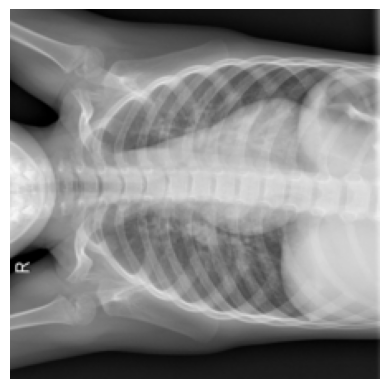

In [8]:
img, label = train_dataset[0]
plt.axis("off")
plt.imshow(img.permute(2, 1, 0))

In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


In [10]:
for pram in model.parameters():
  pram.requires_grad = False;

In [11]:
model.fc = nn.Linear(model.fc.in_features, 2, bias=True)

In [17]:
model.to('cuda')
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [22]:
for epoch in range(3):

  model.train()
  for img, label in train_dataloader:
    img, label = img.to('cuda'), label.to('cuda')

    optimizer.zero_grad()
    pred = model(img)

    loss = loss_fn(pred, label)

    loss.backward()
    optimizer.step()

  model.eval()
  val_total_loss = 0

  with torch.no_grad():

    for img, label in val_dataloader:
      img, label = img.to('cuda'), label.to('cuda')

      pred = model(img)
      loss = loss_fn(pred, label)

      val_total_loss += loss.item()

    print(f'{epoch}: {val_total_loss/len(val_dataloader):.5f}')

0: 0.54673
1: 0.57886
2: 0.56129


In [33]:
test_accuracy_metric = BinaryAccuracy().to('cuda')

model.eval()
test_total_loss = 0

with torch.no_grad():
    for img, label in test_dataloader:
        img, label = img.to('cuda'), label.to('cuda')

        pred = model(img)
        loss = loss_fn(pred, label)
        test_total_loss += loss.item()

        test_accuracy_metric.update(torch.argmax(pred, dim=1), label)

avg_test_loss = test_total_loss / len(test_dataloader)
final_accuracy = test_accuracy_metric.compute() * 100

print(f"📊 Final Test Results:")
print(f"➡️ Average Test Loss: {avg_test_loss:.5f}")
print(f"➡️ Final Test Accuracy: {final_accuracy:.2f}%")

torch.save(model.state_dict(), '05_Pneumonia_X_Ray_Detection.pth')

📊 Final Test Results:
➡️ Average Test Loss: 0.45790
➡️ Final Test Accuracy: 83.20%
🎉 Model weights saved successfully as '05_Pneumonia_X_Ray_Detection.pth'!
